In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from housing_env import HousingEnv

# ensure plots render inline
%matplotlib inline


### Define Simulation Parameters

In [2]:
# environment parameters
num_inspectors = 100
inspection_rate = 4
years = 1  # one year of data
max_active_reports = 1000

# storage for history
history = []

### Build the Simulation Model

In [ ]:
# create environment instance (updated signature requires hierarchical flag and optional data path)
env = HousingEnv(
    num_inspectors=num_inspectors,
    inspection_rate=inspection_rate,
    years=years,
    max_active_reports=max_active_reports,
    hierarchical=True,           # use hierarchical action space
    data_path="data/311_preproc.csv",  # explicit data source
)

### Run the Simulation

In [4]:
# Run the Simulation
obs = env.reset()
for t in range(env.time_steps):
    action = env.action_space.sample()
    obs, reward, done, info = env.step(action)
    history.append({
        'timestep': t,
        'date': info.get('current_date'),
        'open_reports': info['open_reports'],
        'inspections': info['inspections_this_step'],
        'resolved_total': info['total_resolved'],
        'reward': reward,
        'inspection_details': info.get('inspection_details', []),
    })
    if done:
        break

print(f"Completed {len(history)} steps")

ValueError: too many values to unpack (expected 4)

### Process and Export Simulation Data

In [ ]:
hist_df = pd.DataFrame(history)
hist_df.head()

,timestep,date,open_reports,inspections,resolved_total,reward,inspection_details
0,0,2020-01-02,448,211,26,796.2,"[{'report_idx': 8, 'days_outstanding_before': ..."
1,1,2020-01-03,584,322,50,867.6,"[{'report_idx': 903, 'days_outstanding_before'..."
2,2,2020-01-04,548,336,78,954.2,"[{'report_idx': 62, 'days_outstanding_before':..."
3,3,2020-01-05,556,329,112,1048.4,"[{'report_idx': 825, 'days_outstanding_before'..."
4,4,2020-01-06,606,336,142,1032.4,"[{'report_idx': 723, 'days_outstanding_before'..."


### Analysis

<Figure size 1200x500 with 0 Axes>

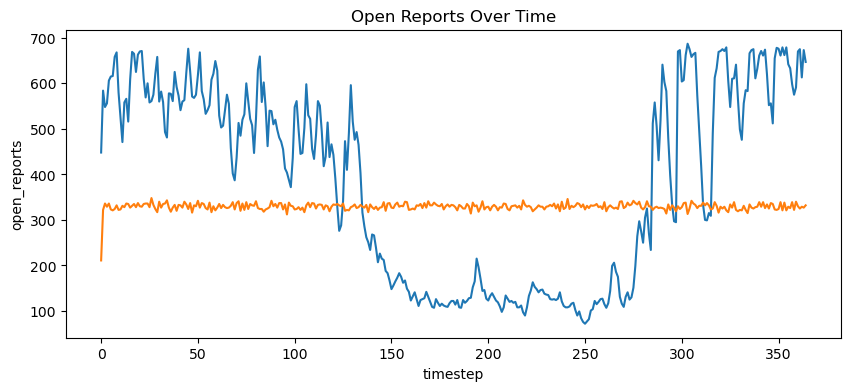

In [ ]:
# plot open reports over time
plt.figure(figsize=(10,4))
sns.lineplot(data=hist_df, x='timestep', y='open_reports')
sns.lineplot(data=hist_df, x='timestep', y='inspections')
plt.title('Open Reports Over Time')
plt.show()

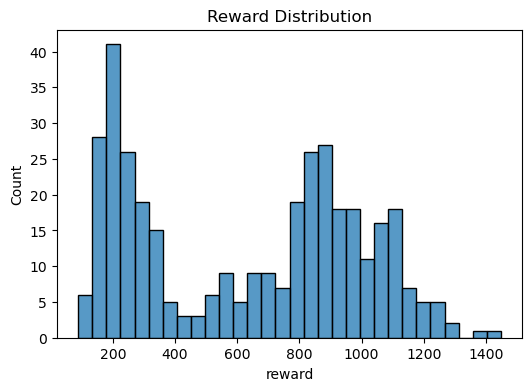

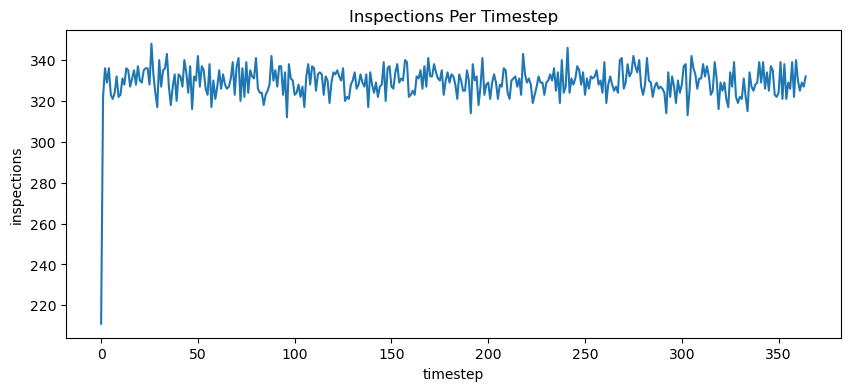

In [ ]:
# histogram of rewards
plt.figure(figsize=(6,4))
sns.histplot(hist_df['reward'], bins=30)
plt.title('Reward Distribution')
plt.show()

# inspections per step
plt.figure(figsize=(10,4))
sns.lineplot(data=hist_df, x='timestep', y='inspections')
plt.title('Inspections Per Timestep')
plt.show()

### Resolution Trends and Days Open

In [ ]:
# helper to convert history list into resolution-level dataframe
def extract_resolution_info(hist):
    rows = []
    for entry in hist:
        for det in entry.get('inspection_details', []):
            rows.append({
                'timestep': entry['timestep'],
                'resolution': det.get('outcome'),
                'days_outstanding': det.get('days_outstanding_before'),
            })
    return pd.DataFrame(rows)

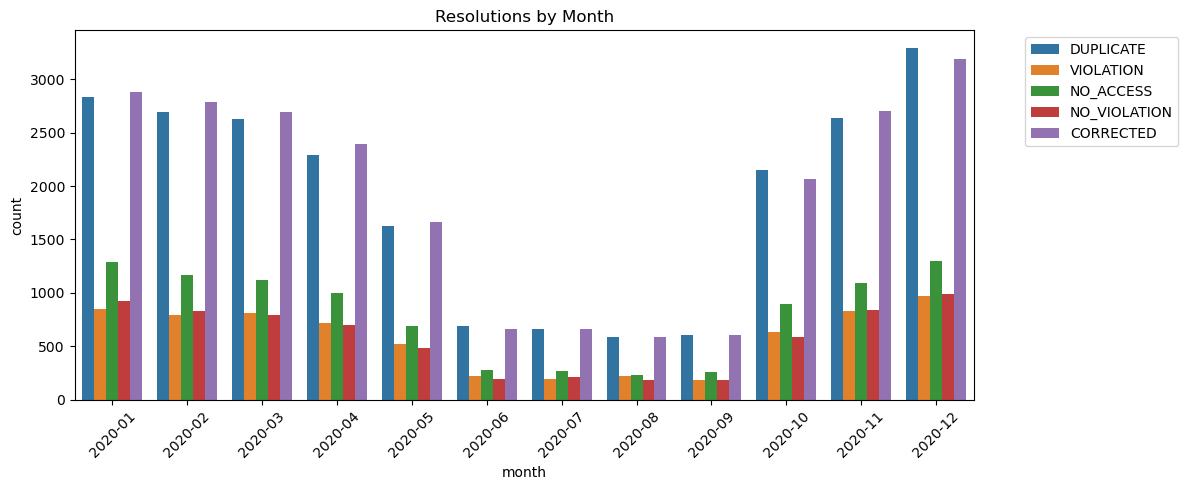

In [ ]:
# compute resolution-level DataFrame from history
res_df = extract_resolution_info(history)

# convert timestep to date using history entries
if len(history) > 0:
    date_map = {entry['timestep']: pd.to_datetime(entry['date']) for entry in history}
    res_df['date'] = res_df['timestep'].map(date_map)
    res_df['month'] = res_df['date'].dt.to_period('M')
else:
    res_df['date'] = pd.NaT
    res_df['month'] = None

# plot stacked counts by month
plt.figure(figsize=(12,5))
sns.countplot(data=res_df, x='month', hue='resolution')
plt.title('Resolutions by Month')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Train RL Agents

This section trains three agents: a random baseline, a TD-learning agent, and a Deep Q-Network.

In [5]:
# Install and Import Stable Baselines3

import subprocess
import sys
from gymnasium import spaces, Wrapper
from stable_baselines3 import DQN
import gymnasium as gym

# Wrapper to flatten Dict observation Space (keeps compatibility with SB3)
class FlattenDictObsWrapper(Wrapper):
    """Convert Dict observation to flattened Box observation for Stable Baselines3."""
    def __init__(self, env):
        super().__init__(env)
        reports_shape = env.observation_space["reports"].shape
        mask_shape = env.observation_space["mask"].shape
        inspectors_shape = env.observation_space["inspectors"].shape if isinstance(env.observation_space["inspectors"], spaces.Box) else (1,)
        timestep_shape = env.observation_space["timestep"].shape if isinstance(env.observation_space["timestep"], spaces.Box) else (1,)
        
        flat_size = (reports_shape[0] * reports_shape[1] + 
                     mask_shape[0] + 
                     (inspectors_shape[0] if isinstance(inspectors_shape, tuple) else 1) +
                     (timestep_shape[0] if isinstance(timestep_shape, tuple) else 1))
        
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(flat_size,),
            dtype=np.float32
        )
    
    def reset(self, **kwargs):
        # Allow seed/options to be passed through; fallback for older envs
        kwargs.pop('seed', None)
        kwargs.pop('options', None)
        obs, info = self.env.reset(**kwargs)
        return self._flatten_obs(obs), info
    
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._flatten_obs(obs), reward, terminated, truncated, info
    
    def _flatten_obs(self, obs):
        # Flatten each component properly
        reports_flat = obs["reports"].flatten().astype(np.float32)
        mask_flat = obs["mask"].astype(np.float32)
        inspectors_flat = np.atleast_1d(np.asarray(obs["inspectors"], dtype=np.float32)).flatten()
        timestep_flat = np.atleast_1d(np.asarray(obs["timestep"], dtype=np.float32)).flatten()
        
        return np.concatenate([reports_flat, mask_flat, inspectors_flat, timestep_flat])

# Simple Random Agent for baseline (works with Discrete hierarchical action space)
class RandomAgent:
    """Baseline agent that takes random actions."""
    def __init__(self, env):
        self.env = env
        self.action_space = env.action_space
    
    def select_action(self, obs):
        return int(self.action_space.sample())

print("Environment wrappers and agent classes ready.")


Environment wrappers and agent classes ready.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [6]:
# Training Configuration

NUM_EVAL_EPISODES = 10  # Evaluation episodes per agent
TRAINING_TIMESTEPS = 50000  # Total training timesteps per agent
YEARS_PER_EPISODE = 0.1  # For random agent evaluation

print("=== Training Configuration ===")
print(f"Training timesteps per agent: {TRAINING_TIMESTEPS:,}")
print(f"Evaluation episodes: {NUM_EVAL_EPISODES}")
print()


=== Training Configuration ===
Training timesteps per agent: 50,000
Evaluation episodes: 10



In [7]:
# Evaluate Random Baseline Agent (hierarchical env)

print("=== Random Agent (Baseline) ===")
random_env = HousingEnv(num_inspectors=100, inspection_rate=4, years=YEARS_PER_EPISODE, max_active_reports=300, hierarchical=True)
random_agent = RandomAgent(random_env)

random_results = []
for ep in range(NUM_EVAL_EPISODES):
    obs, info = random_env.reset()
    done = False
    episode_reward = 0
    violations_resolved = 0
    
    while not done:
        action = random_agent.select_action(obs)
        obs, reward, terminated, truncated, info = random_env.step(action)
        done = terminated or truncated
        episode_reward += reward
        violations_resolved += sum(1 for d in info.get('inspection_details', []) if d.get('outcome') == 'VIOLATION')
    
    random_results.append({
        'total_reward': episode_reward,
        'violations': violations_resolved,
        'open_reports_final': info.get('open_reports', 0)
    })
    
    if (ep + 1) % 5 == 0:
        print(f"  Eval Episode {ep+1}: Reward={episode_reward:.1f}, Violations={violations_resolved}")

print(f"Random - Avg Reward: {np.mean([r['total_reward'] for r in random_results]):.2f} ± {np.std([r['total_reward'] for r in random_results]):.2f}")
print(f"Random - Avg Violations: {np.mean([r['violations'] for r in random_results]):.2f}")
print()


=== Random Agent (Baseline) ===
  Eval Episode 5: Reward=-974.4, Violations=2
  Eval Episode 10: Reward=-942.4, Violations=4
Random - Avg Reward: -958.00 ± 15.23
Random - Avg Violations: 3.00



In [ ]:
# Train a hierarchical Deep Q‑Network using Stable Baselines3

print("=== Training Hierarchical DQN ===")

dqn_env = HousingEnv(
    num_inspectors=100,
    inspection_rate=4,
    years=YEARS_PER_EPISODE,
    max_active_reports=300,
    hierarchical=True,
)
dqn_env = FlattenDictObsWrapper(dqn_env)

model = DQN("MlpPolicy", dqn_env, verbose=1)
model.learn(total_timesteps=TRAINING_TIMESTEPS)
model.save("dqn_hierarchical")

print("DQN training complete (model saved to 'dqn_hierarchical').")

# Evaluate the trained DQN
print("=== Evaluating DQN ===")

dqn_env_eval = HousingEnv(
    num_inspectors=100,
    inspection_rate=4,
    years=YEARS_PER_EPISODE,
    max_active_reports=300,
    hierarchical=True,
)
dqn_env_eval = FlattenDictObsWrapper(dqn_env_eval)

dqn_results = []
for ep in range(NUM_EVAL_EPISODES):
    obs, info = dqn_env_eval.reset()
    done = False
    episode_reward = 0
    violations_resolved = 0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = dqn_env_eval.step(action)
        done = terminated or truncated
        episode_reward += reward
        violations_resolved += sum(
            1 for d in info.get("inspection_details", []) if d.get("outcome") == "VIOLATION"
        )
    dqn_results.append({
        "total_reward": episode_reward,
        "violations": violations_resolved,
        "open_reports_final": info.get("open_reports", 0),
    })
    if (ep + 1) % 5 == 0:
        print(f"  Eval Episode {ep+1}: Reward={episode_reward:.1f}, Violations={violations_resolved}")

print(f"DQN - Avg Reward: {np.mean([r['total_reward'] for r in dqn_results]):.2f} ± {np.std([r['total_reward'] for r in dqn_results]):.2f}")
print(f"DQN - Avg Violations: {np.mean([r['violations'] for r in dqn_results]):.2f}")
print()


=== Training Hierarchical DQN ===
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/opt/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 27.22GB > 1.50GB
  warnings.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 36       |
|    ep_rew_mean      | -906     |
|    exploration_rate | 0.973    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 22       |
|    time_elapsed     | 6        |
|    total_timesteps  | 144      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | nan      |
|    n_updates        | 10       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 36       |
|    ep_rew_mean      | -916     |
|    exploration_rate | 0.945    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 17       |
|    time_elapsed     | 16       |
|    total_timesteps  | 288      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | nan      |
|    n_updates      


=== Agent Comparison (Evaluation Results) ===
             Avg Reward  Avg Violations  Std Reward  Std Violations
Random          34715.0          1031.1      515.52           27.25
Greedy          22697.4           717.0      581.30           31.27
Prioritized     -2434.8            29.7       75.44            3.74


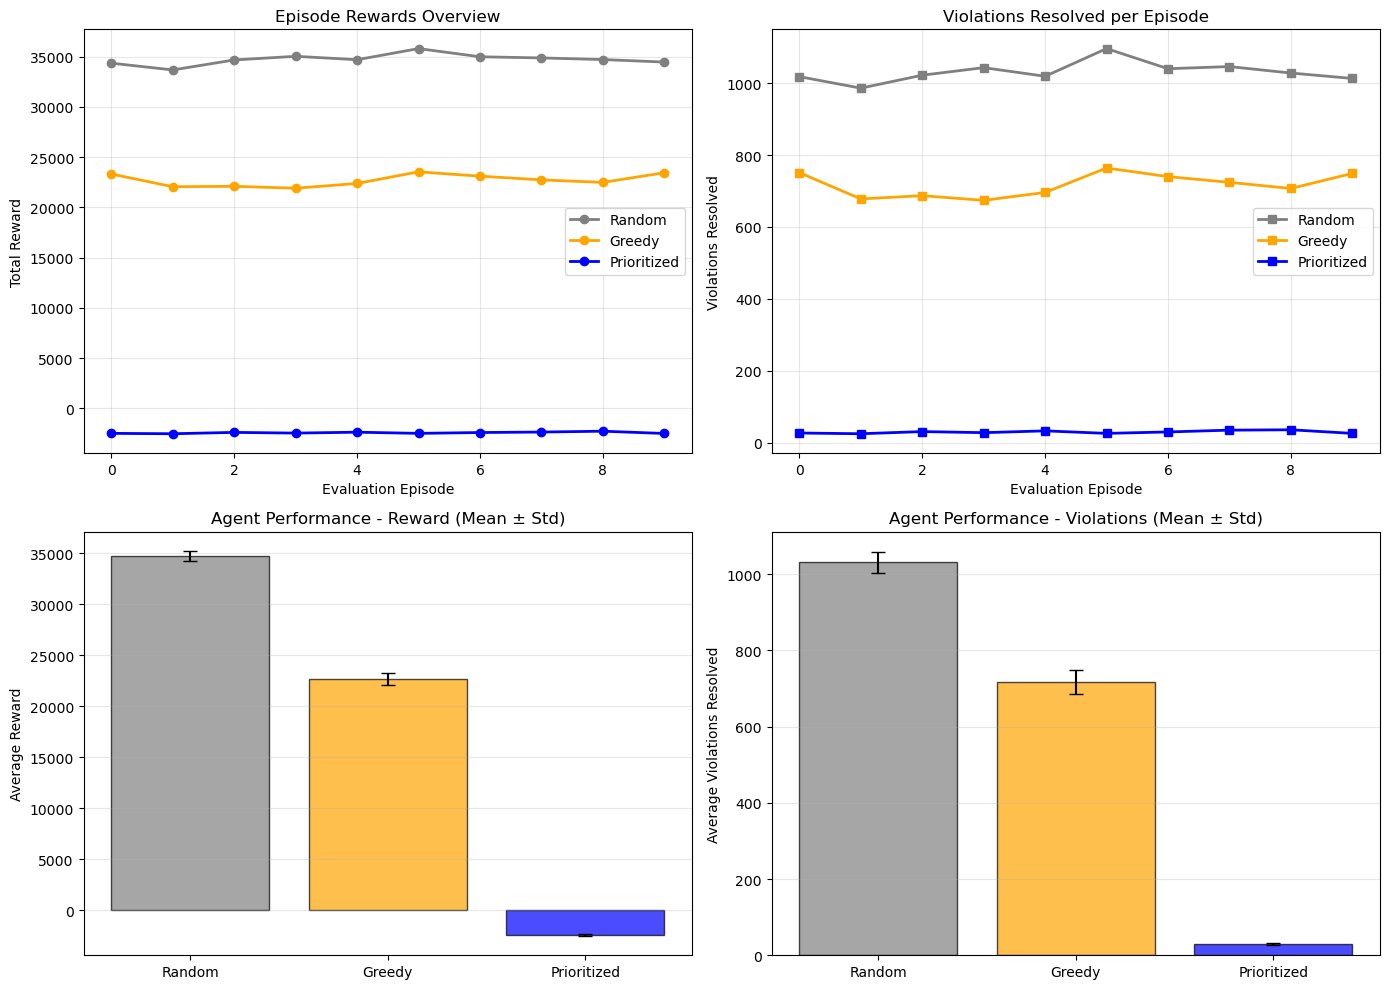


Comparison plot saved as 'agent_comparison.png'


In [ ]:
# Agent Comparison and Visualization

# Prepare comparison data
comparison_df = pd.DataFrame({
    'Random': {
        'Avg Reward': np.mean([r['total_reward'] for r in random_results]),
        'Avg Violations': np.mean([r['violations'] for r in random_results]),
        'Std Reward': np.std([r['total_reward'] for r in random_results]),
        'Std Violations': np.std([r['violations'] for r in random_results])
    },
    'DQN': {
        'Avg Reward': np.mean([r['total_reward'] for r in dqn_results]),
        'Avg Violations': np.mean([r['violations'] for r in dqn_results]),
        'Std Reward': np.std([r['total_reward'] for r in dqn_results]),
        'Std Violations': np.std([r['violations'] for r in dqn_results])
    }
}).T

print("\n=== Agent Comparison (Evaluation Results) ===")
print(comparison_df.round(2))

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Episode rewards over time
agents_list = ['Random', 'DQN']
colors = ['gray', 'blue']
for agent, results, color in zip(agents_list, [random_results, dqn_results], colors):
    rewards = [r['total_reward'] for r in results]
    axes[0, 0].plot(rewards, marker='o', label=agent, color=color, linewidth=2)
axes[0, 0].set_xlabel('Evaluation Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Episode Rewards Overview')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Violations resolved
for agent, results, color in zip(agents_list, [random_results, dqn_results], colors):
    violations = [r['violations'] for r in results]
    axes[0, 1].plot(violations, marker='s', label=agent, color=color, linewidth=2)
axes[0, 1].set_xlabel('Evaluation Episode')
axes[0, 1].set_ylabel('Violations Resolved')
axes[0, 1].set_title('Violations Resolved per Episode')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Average reward comparison (bar chart)
avg_rewards = [comparison_df.loc[agent, 'Avg Reward'] for agent in agents_list]
std_rewards = [comparison_df.loc[agent, 'Std Reward'] for agent in agents_list]
axes[1, 0].bar(agents_list, avg_rewards, yerr=std_rewards, capsize=5, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Average Reward')
axes[1, 0].set_title('Agent Performance - Reward (Mean ± Std)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Average violations comparison (bar chart)
avg_violations = [comparison_df.loc[agent, 'Avg Violations'] for agent in agents_list]
std_violations = [comparison_df.loc[agent, 'Std Violations'] for agent in agents_list]
axes[1, 1].bar(agents_list, avg_violations, yerr=std_violations, capsize=5, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Average Violations Resolved')
axes[1, 1].set_title('Agent Performance - Violations (Mean ± Std)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
